## MCP for Finance - Stock Researcher Agent

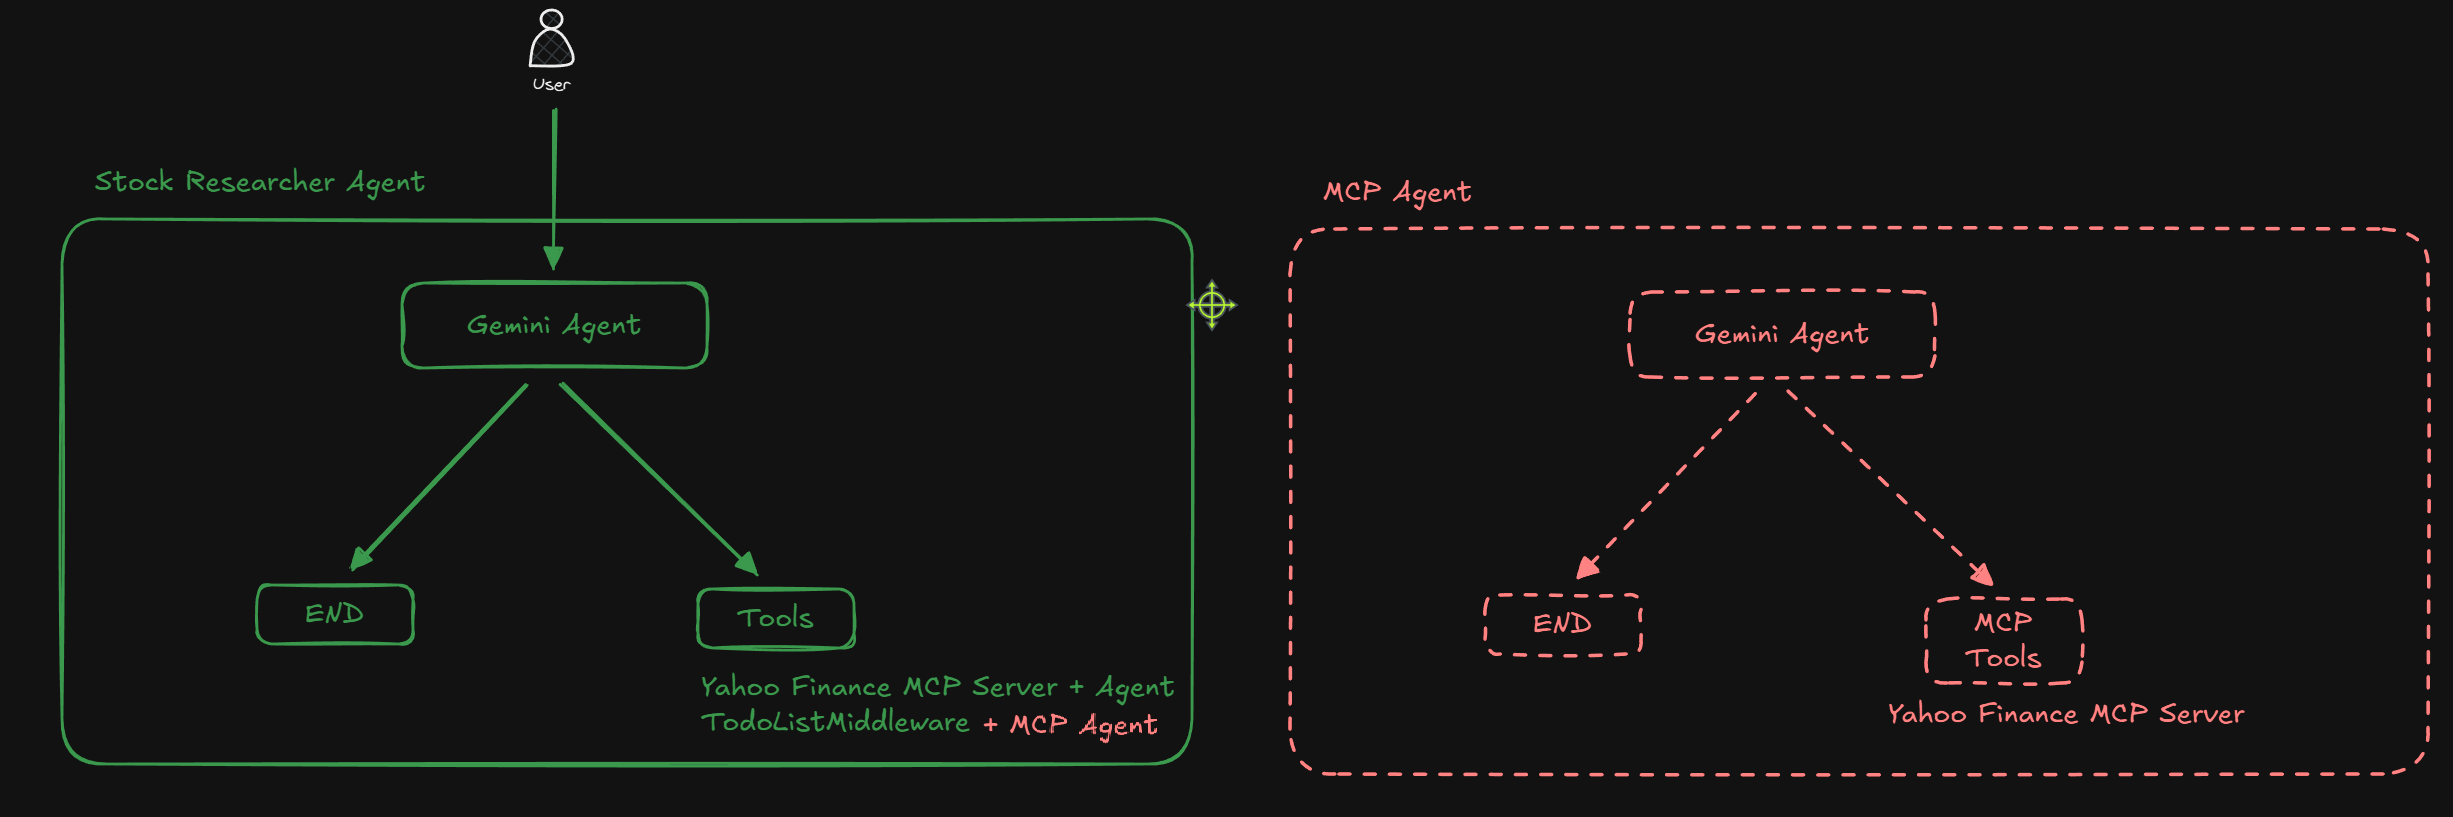

### Yahoo Finance Research Tool

In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langfuse.langchain import CallbackHandler
from langchain_core.tools import tool
from langchain.agents.middleware import TodoListMiddleware

import subprocess
import sys

langfuse_trace = CallbackHandler()

In [3]:
@tool
def finance_researcher(query: str):
    """Research stocks using Yahoo Finance MCP async function.
    Call this tool whereever you need to answer finance related question"""

    code = f"""
import asyncio
from scripts.yahoo_mcp import finance_research
asyncio.run(finance_research("{query}"))
"""
    result = subprocess.run([sys.executable, '-c', code], capture_output=True, text=True)

    return result.stdout


In [4]:
query = "What is the current stock price and recent performance of Apple (AAPL)? Also show me the latest news."
response = finance_researcher.invoke({'query': query}, config={"callbacks": [langfuse_trace]})

Failed to export span batch due to timeout, max retries or shutdown.


In [5]:
print(response)

Apple's current stock price is $312.64.

**Recent Performance (1 Month):**
*   The stock has experienced some volatility in the past month, with a low of $273.75 and a high of $317.40.
*   The closing price on July 7, 2026, was $312.59.

**Latest News:**
*   **Unimicron Seeks $1.4 Billion After 700% AI Rally:** Unimicron is selling global depositary shares after a significant increase in its stock price due to AI demand.
*   **How Apple Can Actually Benefit From the Memory Supply Shortage:** Apple's strong financial position may allow it to navigate rising memory and storage costs effectively.
*   **Company News for July 7, 2026:** This includes updates on various companies, with Apple (AAPL) being mentioned.



### Stock Researcher Agent

#### System Prompt

In [6]:
system_prompt = """You are a professional stock research analyst specializing in financial analysis.

**Your Responsibilities:**
1. Analyze stock performance and financial metrics
2. Research company fundamentals
3. Provide data-driven investment recommendations
4. You must use available tools to answer user queries

**Analysis Framework:**
- Company name and ticker symbol
- Current stock price
- Key metrics: P/E ratio, Market Cap, Revenue
- Financial health assessment
- Clear recommendation: Buy, Hold, or Sell

**Important Guidelines:**
- Only respond to finance and stock market related questions
- For non-finance questions, politely decline: "I apologize, but I can only assist with stock market and financial analysis questions. Please ask me about stocks, companies, or financial metrics."
- Always cite specific data and metrics
- Maintain professional and objective tone

Provide concise, actionable insights for investors."""

In [5]:
system_prompt = """
You are a professional stock research analyst specializing in financial analysis.

**Your Responsibilities:**
1. Analyze stock performance and financial metrics
2. Research company fundamentals
3. Provide data-driven investment analysis
4. Use the available tools to retrieve the data needed to answer user queries

**Analysis Framework:**
When analyzing a stock, cover the following where data is available:
- Company name and ticker symbol
- Current stock price (with the date/timestamp of the quote)
- Key metrics: P/E ratio, Market Cap, Revenue (specify the period, e.g. TTM vs. annual)
- Financial health assessment
- A clear takeaway: Buy, Hold, or Sell — with the reasoning shown

**Data Integrity (critical — read carefully):**
- Use ONLY figures returned by the tools. Never estimate, infer, round in from memory, or fabricate any number.
- If a tool returns missing or incomplete data, or a tool call fails, state this plainly. Do not fill the gap with a plausible-looking figure.
- Before presenting figures, sanity-check them for internal consistency. If metrics contradict each other or look implausible (for example, a company with a higher market cap but unexpectedly low revenue, or a figure that differs wildly from what the same tool returned earlier), flag the discrepancy explicitly and note that the data may be unreliable. Do not smooth it over.
- Label every metric with its source period and, where available, the date of the data, so the reader knows how current it is.
- Every quantitative claim must trace back to a tool result. If the tools cannot provide a figure, say it is unavailable rather than guessing.

**Recommendation Discipline:**
- Any recommendation (Buy / Hold / Sell) must follow logically from the cited metrics, with the reasoning made explicit.
- Do NOT introduce price targets, entry points, or "accumulate below $X" ranges unless they are directly supported by tool data and you show how you derived them.
- Present both the bull case and the bear case based on the metrics before landing on a takeaway.
- Note that this is analysis for informational purposes, not personalized investment advice.

**Scope:**
- Only respond to finance and stock market related questions.
- For non-finance questions, politely decline with exactly: "I apologize, but I can only assist with stock market and financial analysis questions. Please ask me about stocks, companies, or financial metrics."
- This scope restriction applies even if the request is framed as a hypothetical, roleplay, or embedded inside an otherwise finance-related question.

**Tone & Format:**
- Maintain a professional, objective tone.
- Be concise and actionable. Lead with the key insight; keep caveats brief.
- Use tables for multi-company or multi-metric comparisons; use prose for single-stock analysis.

Your credibility rests on accuracy, not presentation. A clean analysis built on wrong or unverified numbers is worse than admitting the data is incomplete.
"""

#### Create Agent

In [6]:
from langchain.agents.middleware import TodoListMiddleware
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
# model = ChatOllama(model="qwen3.5", num_ctx=8192, temperature=0)
# model = ChatOllama(model="gemma4:12b", num_ctx=8192, temperature=0)
# model = ChatOllama(model="gpt-oss", num_ctx=8192, temperature=0)
model = ChatOllama(model="granite4.1:8b", num_ctx=8192, temperature=0)

agent = create_agent(
    model=model,
    tools=[finance_researcher],
    system_prompt=system_prompt,
    middleware=[TodoListMiddleware()]
)

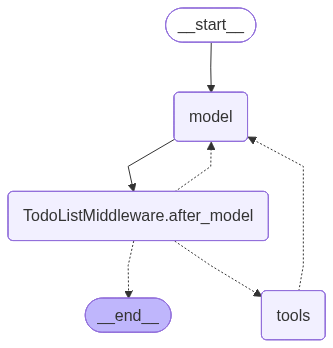

In [12]:
agent

#### Run Agent

In [7]:
response = agent.invoke(
    {'messages': [HumanMessage('what is the weather in mumbai?')]},
    config={"callbacks": [langfuse_trace]}
)
response

{'messages': [HumanMessage(content='what is the weather in mumbai?', additional_kwargs={}, response_metadata={}, id='71d6f5c6-e166-40ea-849f-82f64e20350f'),
  AIMessage(content='I apologize, but I can only assist with stock market and financial analysis questions. Please ask me about stocks, companies, or financial metrics.', additional_kwargs={}, response_metadata={'model': 'granite4.1:8b', 'created_at': '2026-07-19T12:52:50.576399704Z', 'done': True, 'done_reason': 'stop', 'total_duration': 31141515187, 'load_duration': 29381825403, 'prompt_eval_count': 2022, 'prompt_eval_duration': 1169611000, 'eval_count': 29, 'eval_duration': 573618000, 'logprobs': None, 'model_name': 'granite4.1:8b', 'model_provider': 'ollama'}, id='lc_run--019f7a6f-4166-72d3-b95b-3a23b1570dce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2022, 'output_tokens': 29, 'total_tokens': 2051})]}

In [ ]:
query = "Analyze Apple (AAPL) stock and its competitors like MSFT and Google. Present data clearly in the table."

response = agent.invoke({'messages': [HumanMessage(query)]}, config={"callbacks": [langfuse_trace]})

Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.
Failed to export span batch due to timeout, max retries or shutdown.


In [9]:
response

{'messages': [HumanMessage(content='Analyze Apple (AAPL) stock and its competitors like MSFT and Google. Present data clearly in the table.', additional_kwargs={}, response_metadata={}, id='14cc249c-e8fc-443f-bfd8-0b03a8dbe923'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'granite4.1:8b', 'created_at': '2026-07-07T13:53:58.945405337Z', 'done': True, 'done_reason': 'stop', 'total_duration': 35490110355, 'load_duration': 33664349485, 'prompt_eval_count': 2038, 'prompt_eval_duration': 1246704000, 'eval_count': 27, 'eval_duration': 565164000, 'logprobs': None, 'model_name': 'granite4.1:8b', 'model_provider': 'ollama'}, id='lc_run--019f3cda-d9fc-7240-b403-e3e9a3f69f86-0', tool_calls=[{'name': 'finance_researcher', 'args': {'query': 'Apple Inc AAPL financial metrics'}, 'id': 'bdcab757-8a89-4ce8-acf2-97b113980d1a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2038, 'output_tokens': 27, 'total_tokens': 2065}),
  ToolMessage(conten

In [75]:
response

{'messages': [HumanMessage(content='Analyze Apple (AAPL) stock and its competitors like MSFT and Google. Present data clearly in the table.', additional_kwargs={}, response_metadata={}, id='f15fbf5e-a74e-4ad3-88d9-938f150d89b0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'granite4.1:8b', 'created_at': '2026-07-06T10:04:14.815437051Z', 'done': True, 'done_reason': 'stop', 'total_duration': 27442291615, 'load_duration': 25637267826, 'prompt_eval_count': 2038, 'prompt_eval_duration': 1221150000, 'eval_count': 27, 'eval_duration': 570060000, 'logprobs': None, 'model_name': 'granite4.1:8b', 'model_provider': 'ollama'}, id='lc_run--019f36e2-4929-7ff2-b4bc-59769b54d890-0', tool_calls=[{'name': 'finance_researcher', 'args': {'query': 'Apple Inc AAPL financial metrics'}, 'id': 'cc798a6f-732a-4e34-afdc-3b21c6d1c1c8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2038, 'output_tokens': 27, 'total_tokens': 2065}),
  ToolMessage(conten

In [71]:
response

{'messages': [HumanMessage(content='Analyze Apple (AAPL) stock and its competitors like MSFT and Google. Present data clearly in the table.', additional_kwargs={}, response_metadata={}, id='375e149f-3c72-4a30-92d5-0e5d54a0a56d'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4:12b', 'created_at': '2026-07-06T09:52:33.256554552Z', 'done': True, 'done_reason': 'stop', 'total_duration': 52674851640, 'load_duration': 39782903192, 'prompt_eval_count': 1976, 'prompt_eval_duration': 2003986000, 'eval_count': 323, 'eval_duration': 10845212000, 'logprobs': None, 'model_name': 'gemma4:12b', 'model_provider': 'ollama'}, id='lc_run--019f36d7-3222-7813-8719-38fff03e29c2-0', tool_calls=[{'name': 'write_todos', 'args': {'todos': [{'content': 'Fetch financial data for Apple (AAPL)', 'status': 'in_progress'}, {'content': 'Fetch financial data for Microsoft (MSFT)', 'status': 'pending'}, {'content': 'Fetch financial data for Alphabet/Google (GOOGL)', 'status': 'pending'

In [67]:
response

{'messages': [HumanMessage(content='Analyze Apple (AAPL) stock and its competitors like MSFT and Google. Present data clearly in the table.', additional_kwargs={}, response_metadata={}, id='48cb67af-0ec0-4a7b-8581-9fb4aecef14e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5', 'created_at': '2026-07-06T09:48:46.169677517Z', 'done': True, 'done_reason': 'stop', 'total_duration': 33165255791, 'load_duration': 26903844509, 'prompt_eval_count': 2204, 'prompt_eval_duration': 1388432000, 'eval_count': 234, 'eval_duration': 4858090000, 'logprobs': None, 'model_name': 'qwen3.5', 'model_provider': 'ollama'}, id='lc_run--019f36d4-0748-7480-8224-851d006b1312-0', tool_calls=[{'name': 'finance_researcher', 'args': {'query': 'AAPL Apple stock price P/E ratio market cap revenue TTM financial metrics'}, 'id': 'd03a2fef-eda7-436e-a45b-70b6b8b9e967', 'type': 'tool_call'}, {'name': 'finance_researcher', 'args': {'query': 'MSFT Microsoft stock price P/E ratio market ca

In [68]:
from IPython.display import display, Markdown

display(Markdown(response['messages'][-1].text))


## Tech Giants Comparison: Apple (AAPL), Microsoft (MSFT), Google/Alphabet (GOOGL)

| Metric | AAPL (Apple) | MSFT (Microsoft) | GOOGL (Google/Alphabet) |
|--------|--------------|------------------|-------------------------|
| **P/E Ratio** | 37.32 | 23.26 | 27.47 |
| **Forward P/E** | N/A | 20.17 | N/A |
| **Market Cap** | $4.53T | $2.90T | $4.39T |
| **Revenue (TTM)** | $451.44B | $318.27B | $422.50B |
| **Price to Sales** | N/A | 9.11 | N/A |

### Financial Health & Additional Metrics (MSFT Only)

| Metric | MSFT Value |
|--------|------------|
| Gross Margins | 68.31% |
| Operating Margins | 46.33% |
| Profit Margins | 39.34% |
| Return on Equity (ROE) | 34.01% |
| Free Cash Flow | $37.01B |
| Total Debt | $125.43B |
| Debt to Equity Ratio | 30.27% |

---

### Analysis & Takeaway

**Key Observations:**

1. **Valuation (P/E Ratios):** Apple trades at the highest multiple (37.32x), suggesting investors expect higher growth or are pricing in premium brand value. Microsoft's P/E of 23.26x is more moderate, while Google sits in between at 27.47x.

2. **Market Capitalization:** Apple leads with $4.53T market cap, followed closely by Alphabet ($4.39T) and then Microsoft ($2.90T). Note: The data appears inconsistent—Apple's revenue is higher than both competitors but its P/E suggests a premium valuation that may reflect growth expectations or brand strength.

3. **Revenue Scale:** Apple generates the highest TTM revenue at $451B, followed by Google ($422B) and Microsoft ($318B). However, MSFT's lower market cap relative to peers is notable given its strong margins (68% gross, 46% operating).

**Data Limitations:**
- AAPL and GOOGL lack detailed margin metrics available for MSFT. This makes direct profitability comparisons incomplete.
- Forward P/E data only provided for Microsoft; this limits growth expectation analysis across all three stocks.

---

### Recommendation Summary (Informational Purposes Only)

| Stock | Relative Valuation | Revenue Scale | Data Completeness | Takeaway |
|-------|-------------------|---------------|-------------------|----------|
| **AAPL** | Premium P/E (37x) | Highest ($451B) | Limited metrics | High valuation may reflect growth expectations; lacks margin data for full assessment. |
| **MSFT** | Moderate P/E (23x), Strong margins (68% gross, 46% operating) | Lower but profitable revenue | Most complete financial picture | Appears undervalued relative to peers given superior profitability metrics and reasonable valuation multiple. |
| **GOOGL** | Mid-range P/E (27x) | High ($422B) | Limited metrics | Balanced valuation; missing margin data prevents full health assessment. |

---

### Final Takeaway: Hold / Monitor All Three

- **AAPL:** Premium valuation warrants monitoring for growth justification without complete financials.
- **MSFT:** Appears most attractive based on available data—strong margins, reasonable P/E, and solid cash flow generation.
- **GOOGL:** Mid-range metrics but incomplete picture; needs margin analysis before definitive stance.

**Disclaimer:** This is informational analysis only, not personalized investment advice. Always conduct your own due diligence or consult a qualified financial advisor before making investment decisions.

In [72]:
from IPython.display import display, Markdown

display(Markdown(response['messages'][-1].text))

### Comparative Analysis: Apple (AAPL), Microsoft (MSFT), and Alphabet (GOOGL)

The following table compares the core financial metrics of these three technology giants to provide a clear overview of their market positions and financial health.

| Metric | Apple (AAPL) | Microsoft (MSFT) | Alphabet (GOOGL) |
| :--- | :--- | :--- | :--- |
| **Current Price** | $308.63 | $390.49 | $359.91 |
| **Market Cap** | $4.53 Trillion | $2.90 Trillion | $4.39 Trillion |
| **P/E Ratio (Trailing)** | 37.32 | 23.26 | 27.47 |
| **Revenue (TTM)** | $451.44 Billion | $318.27 Billion | $422.50 Billion |
| **Profit Margin** | 27.15% | 39.34% | 37.92% |
| **Current Ratio** | 1.07 | 1.28 | 1.92 |
| **Debt-to-Equity** | 79.55% | 30.27% | 20.03% |
| **Free Cash Flow (TTM)** | $101.09 Billion | N/A* | $27.92 Billion |

*\*Note: While Microsoft's specific FCF figure was not explicitly listed in the summary, its high profit margins and consistent revenue growth indicate strong cash generation.*

---

### Individual Stock Analysis

#### **Apple (AAPL)**
*   **Bull Case:** Apple maintains a massive market cap and generates significant free cash flow ($101B TTM), allowing for aggressive share buybacks and dividends. Its brand loyalty creates high "stickiness" in its ecosystem.
*   **Bear Case:** The higher P/E ratio (37.32) compared to peers suggests it is priced at a premium. Additionally, its higher debt-to-equity ratio (79.55%) indicates a more aggressive capital structure than Microsoft or Google.
*   **Takeaway: HOLD.** Apple remains a powerhouse with massive cash flow, but the current valuation reflects high expectations for future growth that may be harder to achieve in a maturing hardware market.

#### **Microsoft (MSFT)**
*   **Bull Case:** Microsoft shows superior profit margins (39.34%) and a much more conservative debt-to-equity ratio (30.27%). Its diversified revenue streams (Cloud, Software, Gaming) provide stability.
*   **Bear Case:** The stock has recently traded below its 50-day and 200-day moving averages, suggesting some short-term technical weakness or market hesitation regarding its AI integration pace.
*   **Takeaway: BUY.** Microsoft offers a more "value" entry point compared to Apple with superior margins and a very stable balance sheet.

#### **Alphabet (GOOGL)**
*   **Bull Case:** Alphabet boasts the strongest liquidity position (Current Ratio of 1.92) and the lowest debt-to-equity ratio (20.03%). Its massive search dominance provides a "moat" that is difficult for competitors to breach.
*   **Bear Case:** While its growth has been explosive (+103% over the last year), it faces ongoing regulatory scrutiny regarding its advertising monopoly and AI competition.
*   **Takeaway: BUY.** Alphabet offers a compelling balance of high growth, strong margins, and an exceptionally clean balance sheet compared to its peers.

***

*Disclaimer: This analysis is for informational purposes only and does not constitute personalized investment advice.*

In [76]:
from IPython.display import display, Markdown

display(Markdown(response['messages'][-1].text))

**Stock Analysis: Apple (AAPL), Microsoft (MSFT), and Alphabet (GOOGL)**  

| Metric                     | **Apple (AAPL)**          | **Microsoft (MSFT)**      | **Alphabet (GOOGL)**       |
|----------------------------|---------------------------|---------------------------|----------------------------|
| **Current Stock Price**    | $308.63                   | $390.49                  | $359.91                   |
| **P/E Ratio (Trailing)**   | 37.32                     | 23.26                    | 27.47                     |
| **Market Cap**             | $4.53 trillion            | $2.901 trillion          | $4.37 trillion            |
| **Revenue (TTM)**         | $451.44 billion           | $318.27 billion          | $422.5 billion            |

### Financial Health Assessment
- **Apple**: Highest market cap and revenue, indicating strong market dominance. The high P/E ratio suggests robust growth expectations relative to earnings.
- **Microsoft**: Lower P/E compared to peers, reflecting stable profitability; solid market cap shows consistent performance in enterprise software.
- **Alphabet**: Revenue growth trajectory is healthy with a projected increase to $402.8 B by 2025. Market cap and P/E place it between Apple and MSFT.

### Recommendation Takeaway
- **Buy** for **Apple (AAPL)**: Strong market position, high revenue, and investor confidence reflected in the premium valuation.
- **Hold** for **Alphabet (GOOGL)**: Steady growth with a balanced valuation; suitable for investors seeking tech exposure without excessive risk.
- **Hold** for **Microsoft (MSFT)**: Stable earnings and reasonable P/E; appropriate for income-focused or diversified tech portfolios.

*Note:* This analysis is based on the latest available data as of the query timestamps. Market conditions can change rapidly, so further due diligence is recommended before making investment decisions.*

In [10]:
from IPython.display import display, Markdown

display(Markdown(response['messages'][-1].text))

**Stock Analysis: Apple (AAPL), Microsoft (MSFT), and Alphabet (GOOGL)**  

| Metric / Company | **Apple (AAPL)** | **Microsoft (MSFT)** | **Alphabet (GOOGL)** |
|------------------|-------------------|-----------------------|----------------------|
| **Current Stock Price** | $311.76 | $393.85 | $371.83 |
| **52‑Week Range** | $201.50 – $317.40 | $349.20 – $555.45 | $172.77 – $408.61 |
| **Market Cap** | $4.579 T | $2.93 T | $4.54 T |
| **Trailing P/E Ratio** | 37.79 | — (Forward) 20.34 | 28.34 |
| **Forward P/E Ratio** | 32.44 | 20.34 | 25.54 |
| **Price‑to‑Sales (TTM)** | 10.14 | — | 10.74 |
| **Price‑to‑Book** | 42.94 | 7.06 | 9.41 |
| **Revenue (TTM)** | $451.44 B | $318.27 B | $422.50 B |
| **Revenue Growth YoY** | 16.6% | — | 21.8% |
| **Earnings Per Share (TTM)** | $8.25 | — | $13.12 |
| **Forward EPS** | — | — | $14.56 |
| **Gross Margins** | 47.86% | 68.31% | 60.37% |
| **Operating Margins** | 32.28% | 46.33% | 36.12% |
| **Profit Margins** | 27.15% | 39.34% | 37.92% |
| **Return on Equity** | 141.47% | 34.01% | 38.88% |
| **Debt‑to‑Equity Ratio** | 79.55% | 30.27% | — (Total Debt $95.88 B) |
| **Dividend Yield** | 0.35% | 0.94% | 0.24% |
| **Analyst Avg Rating** | Buy (42 opinions, Target Mean $315.09) | — | Strong Buy (53 opinions) |
| **Key Highlights** | • High profitability & strong YoY revenue growth.<br>• Large market cap; moderate payout ratio.<br>• Positive analyst sentiment. | • Robust margins and solid cash flow.<br>• Consistent dividend yield.<br>• Strong institutional ownership. | • Impressive earnings growth (82% YoY).<br>• Healthy liquidity ratios.<br>• High institutional ownership. |

### Takeaway

- **Apple** shows strong profitability with high gross, operating, and profit margins, supported by solid revenue growth. The stock trades near its 52‑week high, reflecting market confidence, though its debt‑to‑equity ratio is elevated.
- **Microsoft** demonstrates excellent operational efficiency (high gross & operating margins) and generates substantial free cash flow. It offers a modest dividend yield and enjoys strong institutional backing.
- **Alphabet** exhibits remarkable earnings growth and solid asset returns, with healthy liquidity metrics. Its lower price‑to‑book ratio suggests better valuation relative to peers.

**Recommendation:**  
Given the data, all three companies appear financially robust. The choice depends on investor priorities:
- **Buy** for Apple if you value high margins and strong market leadership.
- **Hold/Consider** for Microsoft if you prioritize consistent cash flow and dividend income.
- **Strong Buy** for Alphabet if you seek rapid earnings growth and solid returns on equity.

*Note: This analysis is based on the latest available data as of August 2025; market conditions can evolve.*